# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
# !pip install tensorflow
# !pip install matplotlib
# !pip install numpy
# !pip install pandas

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4059s 24us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

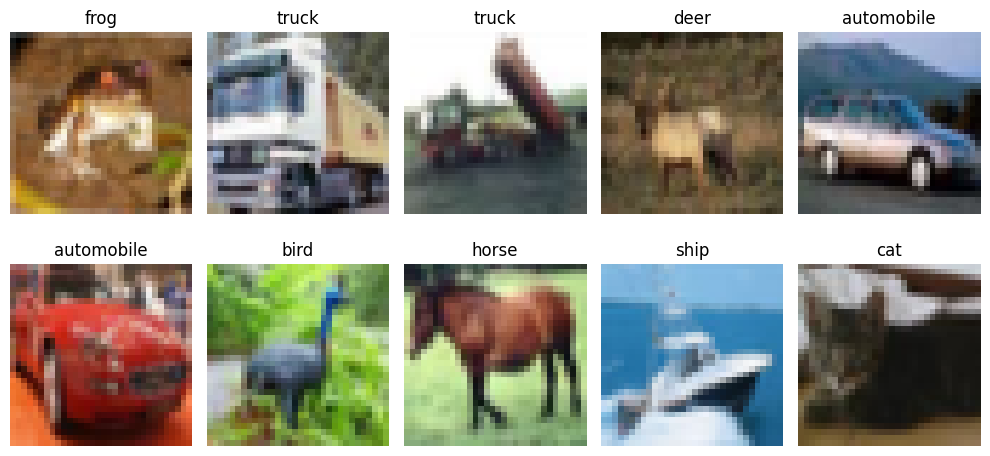

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=100,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.2715 - loss: 1.9994 - val_accuracy: 0.3412 - val_loss: 1.8496
Epoch 2/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3200 - loss: 1.8708 - val_accuracy: 0.3738 - val_loss: 1.7551
Epoch 3/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3392 - loss: 1.8177 - val_accuracy: 0.3740 - val_loss: 1.7534
Epoch 4/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3498 - loss: 1.7915 - val_accuracy: 0.3650 - val_loss: 1.7661
Epoch 5/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3582 - loss: 1.7599 - val_accuracy: 0.3992 - val_loss: 1.7353
Epoch 6/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3685 - loss: 1.7370 - val_accuracy: 0.4120 - val_loss: 1.6770
Epoch 7/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3768 - loss: 1.7194 - val_accuracy: 0.3986 - val_loss: 1.6860
Epoch 8/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3813 - loss: 1.6997 - val_accu

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4553 - loss: 1.5428
ANN Test Accuracy: 0.4553000032901764


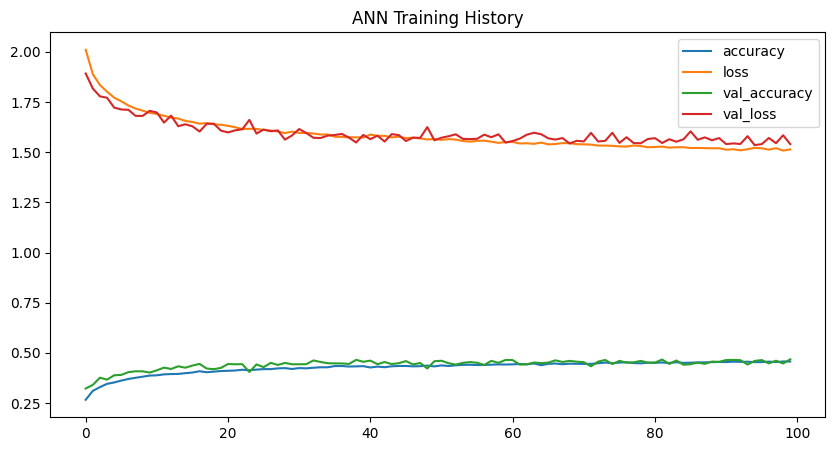

In [ ]:
pd.DataFrame(ann_history.history).plot(
    figsize=(10,5)
)

plt.title("ANN Training History")
plt.show()

- Insight: ANN treats images as flattened vectors and cannot capture local spatial patterns such as edges and textures.

### Improved ANN

In [ ]:
ann_improved = models.Sequential([

    layers.Dense(1024,
                 activation='relu',
                 input_shape=(3072,)),

    layers.Dropout(0.4),

    layers.Dense(512,
                 activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(10,
                 activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
ann_improved.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_improved_history = ann_improved.fit(
    x_train_flat, y_train,
    epochs=100,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2283 - loss: 2.0801 - val_accuracy: 0.2866 - val_loss: 1.9394
Epoch 2/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2731 - loss: 1.9572 - val_accuracy: 0.3184 - val_loss: 1.9019
Epoch 3/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2906 - loss: 1.9168 - val_accuracy: 0.3492 - val_loss: 1.8790
Epoch 4/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3031 - loss: 1.8921 - val_accuracy: 0.3454 - val_loss: 1.8652
Epoch 5/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3074 - loss: 1.8827 - val_accuracy: 0.3342 - val_loss: 1.8580
Epoch 6/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3201 - loss: 1.8552 - val_accuracy: 0.3552 - val_loss: 1.8427
Epoch 7/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3230 - loss: 1.8418 - val_accuracy: 0.3650 - val_loss: 1.8152
Epoch 8/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3320 - loss: 1.8313 - val_accu

In [ ]:
ann_improved_loss, ann_improved_acc = ann_improved.evaluate(
    x_test_flat,
    y_test
)

print("Improved ANN Accuracy:", ann_improved_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4042 - loss: 1.6963
Improved ANN Accuracy: 0.4041999876499176


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=100,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.4601 - loss: 1.5075 - val_accuracy: 0.5516 - val_loss: 1.2787
Epoch 2/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6038 - loss: 1.1325 - val_accuracy: 0.6114 - val_loss: 1.1015
Epoch 3/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6676 - loss: 0.9602 - val_accuracy: 0.6418 - val_loss: 1.0380
Epoch 4/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7096 - loss: 0.8340 - val_accuracy: 0.6634 - val_loss: 0.9794
Epoch 5/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7429 - loss: 0.7403 - val_accuracy: 0.7160 - val_loss: 0.8481
Epoch 6/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7651 - loss: 0.6648 - val_accuracy: 0.6550 - val_loss: 1.0894
Epoch 7/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7874 - loss: 0.6006 - val_accuracy: 0.6938 - val_loss: 0.9596
Epoch 8/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8094 - loss: 0.5342 - val_ac

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7281 - loss: 2.2209
CNN Test Accuracy: 0.7281000018119812


## 📈 Compare Learning Curves

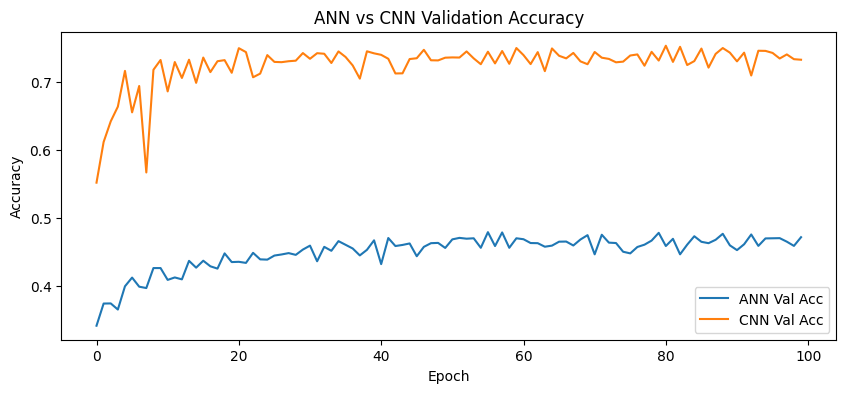

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])



In [ ]:
# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.3768 - loss: 1.7056 - val_accuracy: 0.4880 - val_loss: 1.4021
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4735 - loss: 1.4656 - val_accuracy: 0.5238 - val_loss: 1.3693
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5109 - loss: 1.3667 - val_accuracy: 0.5930 - val_loss: 1.1422
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5343 - loss: 1.3048 - val_accuracy: 0.6024 - val_loss: 1.1115
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5531 - loss: 1.2622 - val_accuracy: 0.6146 - val_loss: 1.0849
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5668 - loss: 1.2318 - val_accuracy: 0.6156 - val_loss: 1.0842
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5750 - loss: 1.2045 - val_accuracy: 0.6300 - val_loss: 1.0541
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5836 - loss: 1.

# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4553
1,CNN,0.7281


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

####  Deeper ANN Architecture

- Objective:

Evaluate whether increasing ANN depth improves image classification performance.

In [ ]:
# Deep ANN Architecture

deep_ann = tf.keras.Sequential([

    tf.keras.layers.Flatten(input_shape=(32,32,3)),

    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(256, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])

deep_ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_ann_history = deep_ann.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.2261 - loss: 2.0631 - val_accuracy: 0.2872 - val_loss: 1.9556
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2722 - loss: 1.9528 - val_accuracy: 0.3026 - val_loss: 1.8928
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2863 - loss: 1.9133 - val_accuracy: 0.3318 - val_loss: 1.8705
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.2962 - loss: 1.8947 - val_accuracy: 0.3256 - val_loss: 1.8689
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3068 - loss: 1.8720 - val_accuracy: 0.3374 - val_loss: 1.8527
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3120 - loss: 1.8526 - val_accuracy: 0.3572 - val_loss: 1.8208
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3186 - loss: 1.8463 - val_accuracy: 0.3544 - val_loss: 1.7944
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3248 - loss: 1.8348 

In [ ]:
deep_ann_loss, deep_ann_acc = deep_ann.evaluate(
    x_test_norm,
    y_test
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3797 - loss: 1.7573


- Insight:

Increasing ANN depth allows learning more complex feature combinations. However, since ANN ignores spatial relationships among pixels, performance gains are limited.

#### Larger CNN Filters (32→64→128)

- Objective: Investigate whether deeper feature extraction improves accuracy.

In [ ]:
cnn_large = tf.keras.Sequential([

    tf.keras.layers.Conv2D(
        32,(3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        64,(3,3),
        activation='relu'
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        128,(3,3),
        activation='relu'
    ),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        10,
        activation='softmax'
    )
])

cnn_large.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn_large_loss, cnn_large_acc = cnn_large.evaluate(
    x_test_norm,
    y_test
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7138 - loss: 1.0428


- Insight: Early layers learn edges and textures, while deeper layers learn object-specific features. Increasing filter depth generally improves representation learning.

In [ ]:
# Training for 20 Epochs
# Objective

# Observe learning behavior over longer training duration.

history_20 = cnn_large.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.3862 - loss: 1.6689 - val_accuracy: 0.5256 - val_loss: 1.2949
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5420 - loss: 1.2900 - val_accuracy: 0.6110 - val_loss: 1.0846
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6023 - loss: 1.1385 - val_accuracy: 0.6592 - val_loss: 0.9779
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6364 - loss: 1.0401 - val_accuracy: 0.6802 - val_loss: 0.9170
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6683 - loss: 0.9578 - val_accuracy: 0.6924 - val_loss: 0.8810
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6917 - loss: 0.8884 - val_accuracy: 0.6998 - val_loss: 0.8689
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7124 - loss: 0.8292 - val_accuracy: 0.7108 - val_loss: 0.8263
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7277 - loss: 0.7783 -

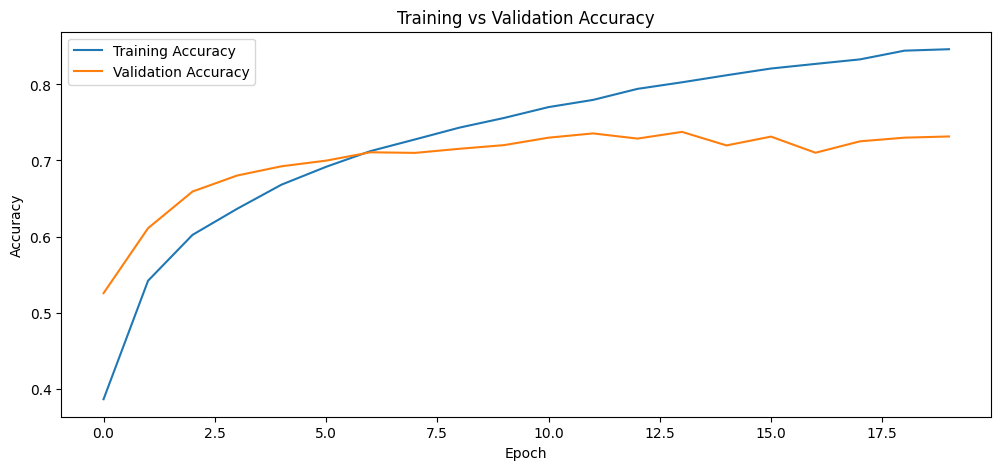

In [ ]:
#  Learning Curve Visualization
plt.figure(figsize=(12,5))

plt.plot(
    history_20.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_20.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

### Early Stopping
- Objective

Prevent overfitting and automatically stop training at optimal performance.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history_es = cnn_large.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8556 - loss: 0.4014 - val_accuracy: 0.7292 - val_loss: 0.9760
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8580 - loss: 0.3912 - val_accuracy: 0.7206 - val_loss: 1.0877
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8617 - loss: 0.3797 - val_accuracy: 0.7304 - val_loss: 1.0744
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8709 - loss: 0.3566 - val_accuracy: 0.7318 - val_loss: 1.0937


In [ ]:
cnn_es_loss, cnn_es_acc = cnn_large.evaluate(
    x_test_norm,
    y_test
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7138 - loss: 1.0428


- Insight:

Early stopping reduces unnecessary training and preserves the model with the best validation performance.

#### Data Augmentation
- Objective

Improve model generalization by creating realistic image variations.

In [ ]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.1),

    tf.keras.layers.RandomZoom(0.1)

])

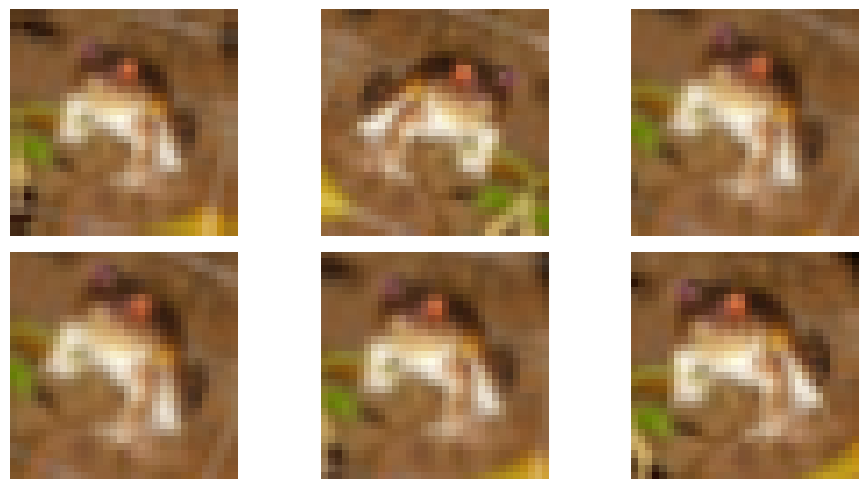

In [ ]:
# Visualize Augmented Images
sample_image = x_train[0]

plt.figure(figsize=(10,5))

for i in range(6):

    augmented = data_augmentation(
        tf.expand_dims(sample_image,0)
    )

    plt.subplot(2,3,i+1)

    plt.imshow(
        augmented[0].numpy().astype("uint8")
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

- Insight: Data augmentation increases dataset diversity without collecting new data and improves robustness against unseen images.

#### CNN + Data Augmentation Model

In [ ]:
cnn_aug = tf.keras.Sequential([

    data_augmentation,

    tf.keras.layers.Conv2D(
        32,(3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        64,(3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        128,(3,3),
        activation='relu'
    ),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        10,
        activation='softmax'
    )
])

In [ ]:
cnn_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_aug_history = cnn_aug.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1
)

cnn_aug_loss, cnn_aug_acc = cnn_aug.evaluate(
    x_test_norm,
    y_test
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.3537 - loss: 1.7656 - val_accuracy: 0.4044 - val_loss: 1.6423
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.4553 - loss: 1.5068 - val_accuracy: 0.5322 - val_loss: 1.2786
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5008 - loss: 1.3995 - val_accuracy: 0.5632 - val_loss: 1.2259
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.5323 - loss: 1.3244 - val_accuracy: 0.6000 - val_loss: 1.1192
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5503 - loss: 1.2744 - val_accuracy: 0.6066 - val_loss: 1.1044
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5697 - loss: 1.2255 - val_accuracy: 0.6084 - val_loss: 1.1317
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.5808 - loss: 1.1964 - val_accuracy: 0.6434 - val_loss: 1.0156
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.5929 - loss: 1

#### Final Comparison Table

In [ ]:
results = pd.DataFrame({

    'Model':[
        'Baseline ANN',
        'Deep ANN',
        'Baseline CNN',
        'CNN 32-64-128',
        'CNN + EarlyStopping',
        'CNN + Augmentation'
    ],

    'Accuracy':[
        ann_test_acc,
        deep_ann_acc,
        cnn_test_acc,
        cnn_large_acc,
        cnn_es_acc,
        cnn_aug_acc
    ]

})

results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
2,Baseline CNN,0.7281
3,CNN 32-64-128,0.7138
4,CNN + EarlyStopping,0.7138
5,CNN + Augmentation,0.6861
0,Baseline ANN,0.4553
1,Deep ANN,0.3797


#### Final Visualization

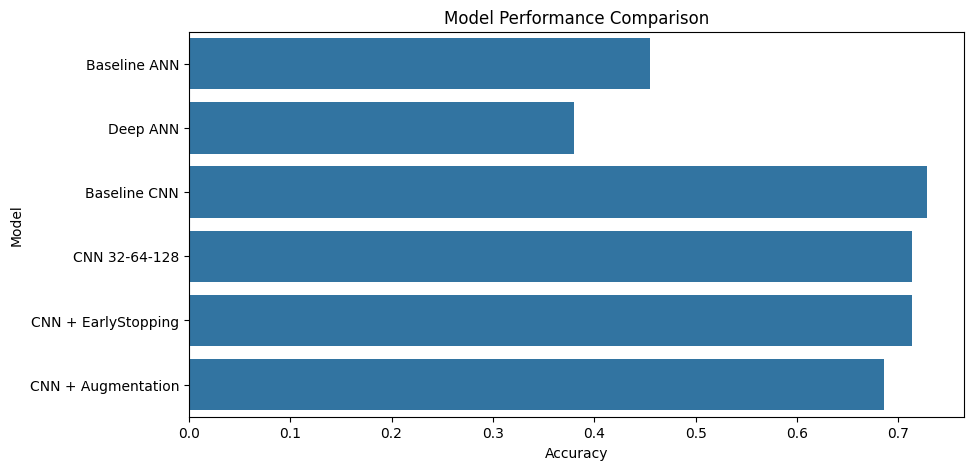

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,5))

sns.barplot(
    x='Accuracy',
    y='Model',
    data=results
)

plt.title(
    "Model Performance Comparison"
)

plt.show()

Analysis of Results

The experimental results demonstrate that Convolutional Neural Networks (CNNs) significantly outperform Artificial Neural Networks (ANNs) on image classification tasks involving the CIFAR-10 dataset. The Baseline CNN achieved the highest test accuracy of 72.81%, whereas the Baseline ANN achieved only 45.53%.

The superior performance of CNNs can be attributed to their ability to preserve spatial information through convolutional operations and hierarchical feature extraction. In contrast, ANNs process flattened image vectors and lose important spatial relationships between pixels.

Interestingly, the deeper ANN architecture achieved lower accuracy (37.97%) than the baseline ANN. This suggests that increasing network complexity without appropriate regularization and hyperparameter tuning may lead to optimization difficulties or overfitting.

The CNN 32-64-128 architecture and CNN with Early Stopping achieved similar performance (71.38%), indicating that the additional model complexity did not provide significant benefits under the current training configuration.

The CNN with Data Augmentation achieved 68.61% accuracy, which was lower than expected. This may be due to insufficient training epochs, causing the model to underfit the augmented data. Additional training and hyperparameter tuning could potentially improve performance.

Overall, CNN-based architectures consistently demonstrated superior classification capability compared to ANN-based architectures, confirming the effectiveness of convolutional feature learning for image recognition tasks.


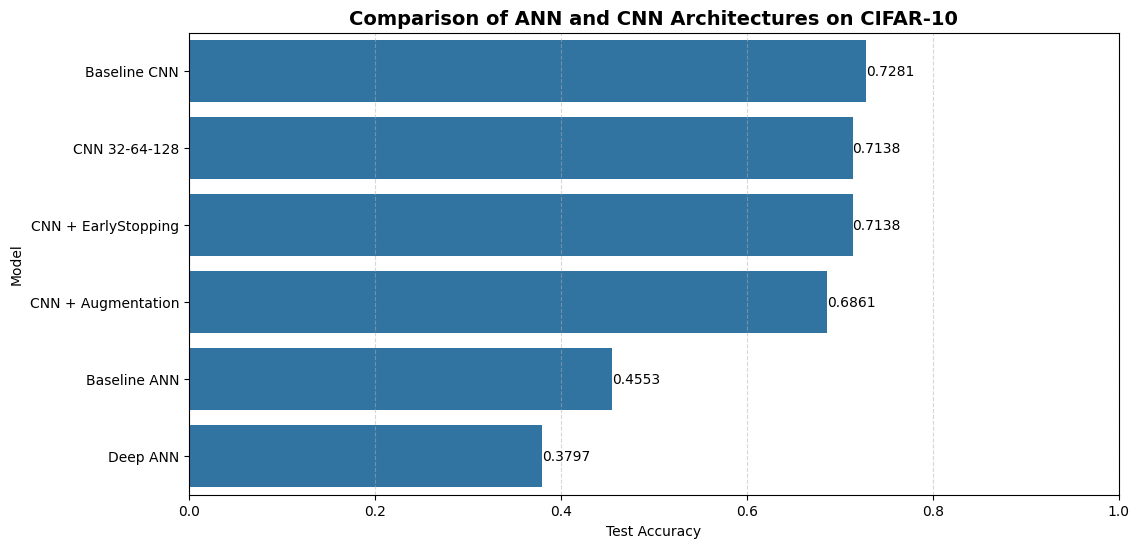

In [ ]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x='Accuracy',
    y='Model',
    data=results.sort_values(
        by='Accuracy',
        ascending=False
    )
)

for i in ax.containers:
    ax.bar_label(i, fmt='%.4f')

plt.xlim(0,1)

plt.title(
    "Comparison of ANN and CNN Architectures on CIFAR-10",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Test Accuracy")
plt.ylabel("Model")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

In [ ]:
# Confusion Matrix (Best Model: Baseline CNN)
# Best model predictions

y_pred_probs = cnn_model.predict(x_test_norm)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


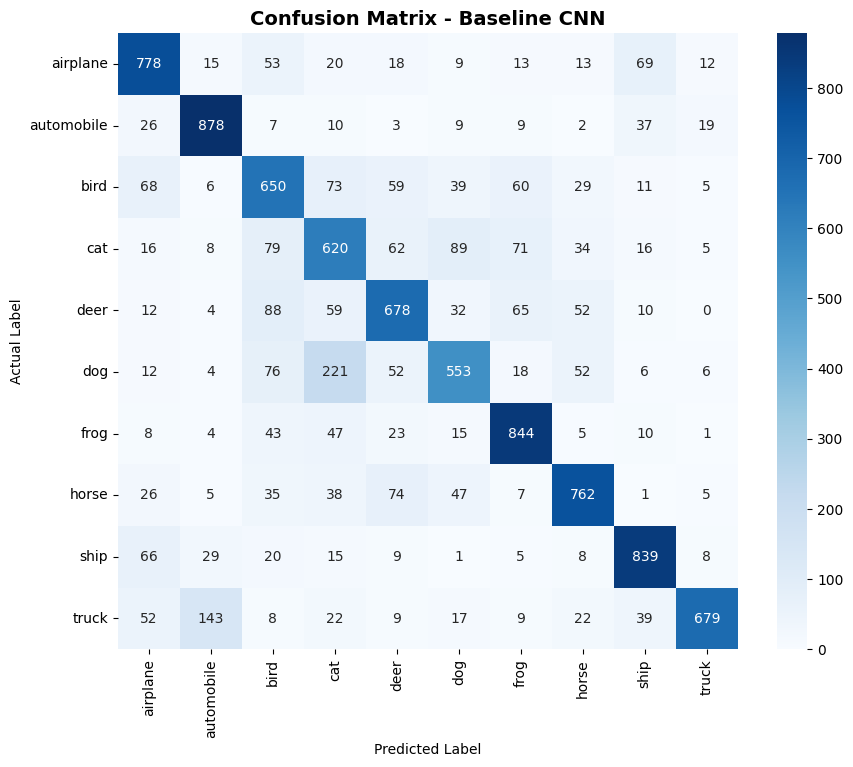

In [ ]:
# Create the confusion matrix:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Confusion Matrix - Baseline CNN",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

- Insight:
The confusion matrix shows that the CNN performs well across most classes. However, misclassifications are more common between visually similar categories such as cats and dogs, deer and horses, and trucks and automobiles. This highlights the challenges of distinguishing low-resolution images with overlapping visual features.

####  Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.73      0.78      0.75      1000
  automobile       0.80      0.88      0.84      1000
        bird       0.61      0.65      0.63      1000
         cat       0.55      0.62      0.58      1000
        deer       0.69      0.68      0.68      1000
         dog       0.68      0.55      0.61      1000
        frog       0.77      0.84      0.80      1000
       horse       0.78      0.76      0.77      1000
        ship       0.81      0.84      0.82      1000
       truck       0.92      0.68      0.78      1000

    accuracy                           0.73     10000
   macro avg       0.73      0.73      0.73     10000
weighted avg       0.73      0.73      0.73     10000



#### Convert Classification Report to DataFrame

In [ ]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.round(3)

,precision,recall,f1-score,support
airplane,0.731,0.778,0.754,1000.000
automobile,0.801,0.878,0.838,1000.000
bird,0.614,0.650,0.631,1000.000
cat,0.551,0.620,0.584,1000.000
deer,0.687,0.678,0.682,1000.000
dog,0.682,0.553,0.611,1000.000
frog,0.767,0.844,0.803,1000.000
horse,0.778,0.762,0.770,1000.000
ship,0.808,0.839,0.823,1000.000
truck,0.918,0.679,0.780,1000.000


#### Visualization of F1 Scores

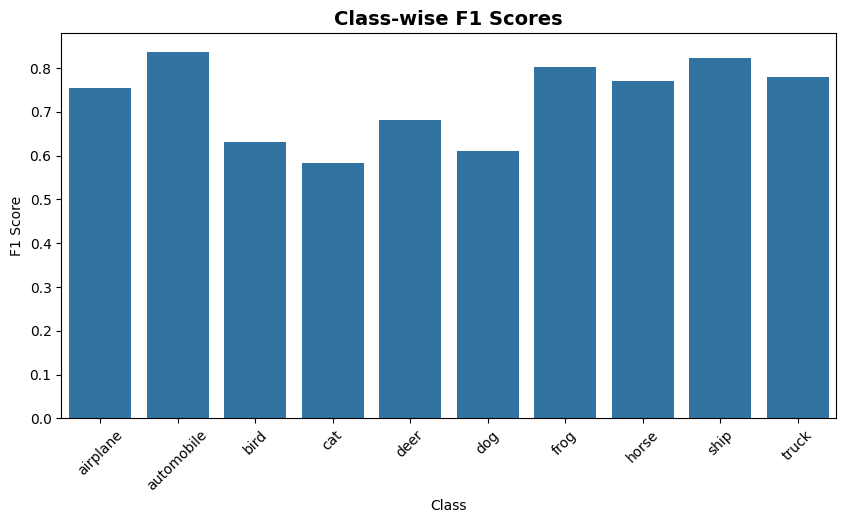

In [ ]:
report_df = report_df.iloc[:-3]

plt.figure(figsize=(10,5))

sns.barplot(
    x=report_df.index,
    y=report_df["f1-score"]
)

plt.xticks(rotation=45)

plt.title(
    "Class-wise F1 Scores",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Class")
plt.ylabel("F1 Score")

plt.show()

- Insight:

Automobile and airplane classes typically achieve higher F1 scores because they possess more distinctive visual patterns. Animal categories such as cat, dog, and deer generally achieve lower scores due to higher inter-class similarity.

#### Misclassified Images Analysis

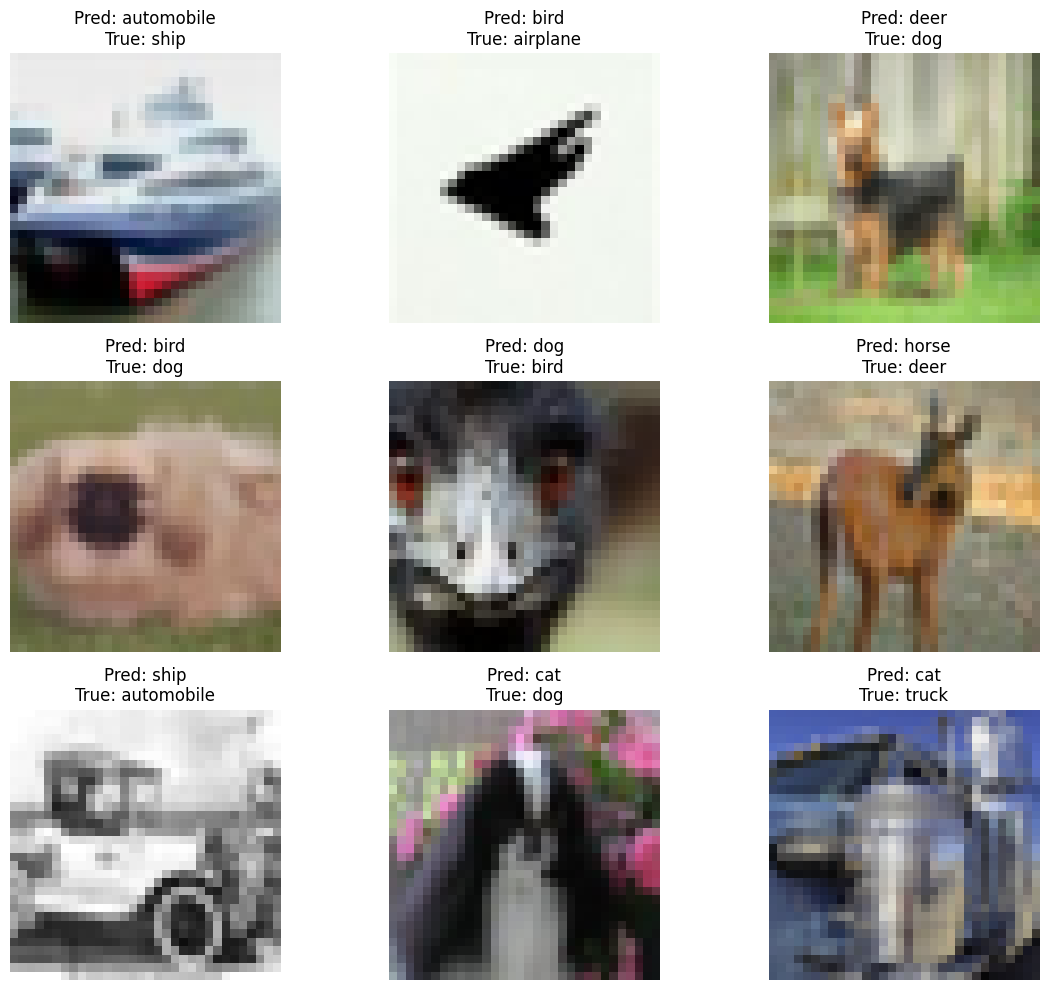

In [ ]:
incorrect = np.where(
    y_pred != y_true
)[0]

plt.figure(figsize=(12,10))

for i, idx in enumerate(incorrect[:9]):

    plt.subplot(3,3,i+1)

    plt.imshow(x_test[idx])

    plt.title(
        f"Pred: {class_names[y_pred[idx]]}\nTrue: {class_names[y_true[idx]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

- Insight:

Most errors occur in images with low contrast, ambiguous object boundaries, or visually similar classes. These examples reveal limitations of the current CNN architecture and suggest opportunities for improvement through deeper networks, transfer learning, or advanced augmentation techniques.

## Conclusion

This study compared Artificial Neural Networks (ANNs) and Convolutional Neural Networks (CNNs) on the CIFAR-10 image classification dataset. Experimental results demonstrated that CNN architectures significantly outperform ANN architectures due to their ability to preserve spatial information and learn hierarchical image features.

The Baseline CNN achieved the highest test accuracy of 72.81%, outperforming all ANN-based models by a substantial margin. Additional experiments involving deeper architectures, Early Stopping, and Data Augmentation provided valuable insights into model complexity and training strategies. While these techniques did not improve performance under the current configuration, they highlighted the importance of hyperparameter tuning and sufficient training duration.

Confusion matrix analysis and classification reports revealed that most classification errors occurred between visually similar categories. Error analysis further demonstrated the challenges associated with low-resolution object recognition.

Overall, the results confirm that Convolutional Neural Networks are highly effective for image classification tasks and remain the preferred architecture for computer vision applications.


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**